In [14]:
from pylib.setup import *
setup_notebook()

import requests, json, gzip
import pylib.groups as g

from itertools import product
from urllib.parse import urlencode

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Automatic fetch `Clean tech` data

### 1. get

*fetch using EUROSTAT API*

In [15]:
base = "https://ec.europa.eu/eurostat/api/comext/dissemination/sdmx/2.1/data/DS-045409"

prod_key = "+".join(map(str, g.products))
rep_key  = "+".join(map(str, g.reporter))

key = f"M.{rep_key}.EXT_EU27_2020.{prod_key}.1+2.VALUE_IN_EUROS"

url = f"{base}/{key}"

params = {"format":         "JSON", 
          "startPeriod":    "2025-01", 
          'endPeriod':      '2026-04',
          "compressed":     "true"
}

r = requests.get(url, params=params, timeout=300)
r.raise_for_status()

raw = r.content
if raw[:2] == b"\x1f\x8b":          # gzip magic
    raw = gzip.decompress(raw)

data = json.loads(raw.decode("utf-8"))

*Set up df*

In [16]:
ids   = data["id"]          # fx ["freq","reporter","partner","product","flow","indicators","time"]
sizes = data["size"]        # samme længde som ids
dims  = data["dimension"]   # dict
vals  = data["value"]       # dict (json-stat: index -> value) eller liste

# 1) hent label-lister for hver dimension i samme rækkefølge som data["id"]
levels = []
for dim in ids:
    cat = dims[dim]["category"]
    idx = cat["index"]
    # idx er typisk dict: {code: position}
    if isinstance(idx, dict):
        codes = [k for k, _ in sorted(idx.items(), key=lambda kv: kv[1])]
    else:
        # sjældent: idx som liste
        codes = list(idx)
    levels.append(codes)

# 2) lav multi-index (alle kombinationer)
mi = pd.MultiIndex.from_product(levels, names=ids)

# 3) values til array i korrekt rækkefølge
# json-stat value kan være dict (sparse) eller liste (dense)
if isinstance(vals, dict):
    y = np.full(mi.size, np.nan, dtype=float)
    for k, v in vals.items():
        y[int(k)] = v
else:
    y = np.asarray(vals, dtype=float)

df = mi.to_frame(index=False)
df["value"] = y

### 2. aggregate

In [17]:
# 1. map to aggregate cetegories
prod2cat = {str(p): cat for cat, ps in g.hs.items() for p in ps}

df["product"] = df["product"].astype(str)
df["category"] = df["product"].map(prod2cat)

# 2. aggregate
agg = (df.groupby(["time", "flow", "category"], as_index=False)["value"]
         .sum()
         .sort_values(["time", "flow", "category"]))

# 3. transpose
flow_map = {"1": "M_EUR", "2": "X_EUR", 1: "M_EUR", 2: "X_EUR"}
tmp = agg.copy()
tmp["flow"] = tmp["flow"].map(flow_map).fillna(tmp["flow"])

wide = (tmp.pivot_table(index=["time", "category"],
                        columns="flow",
                        values="value",
                        aggfunc="sum")
          .reset_index()
          .sort_values(["time", "category"]))


*convert unit from EUR to mia. DKK*

In [18]:
wide['mM_DKK'] = wide.M_EUR * 7.45 * 1e-9
wide['mX_DKK'] = wide.X_EUR * 7.45 * 1e-9

### 3. plot

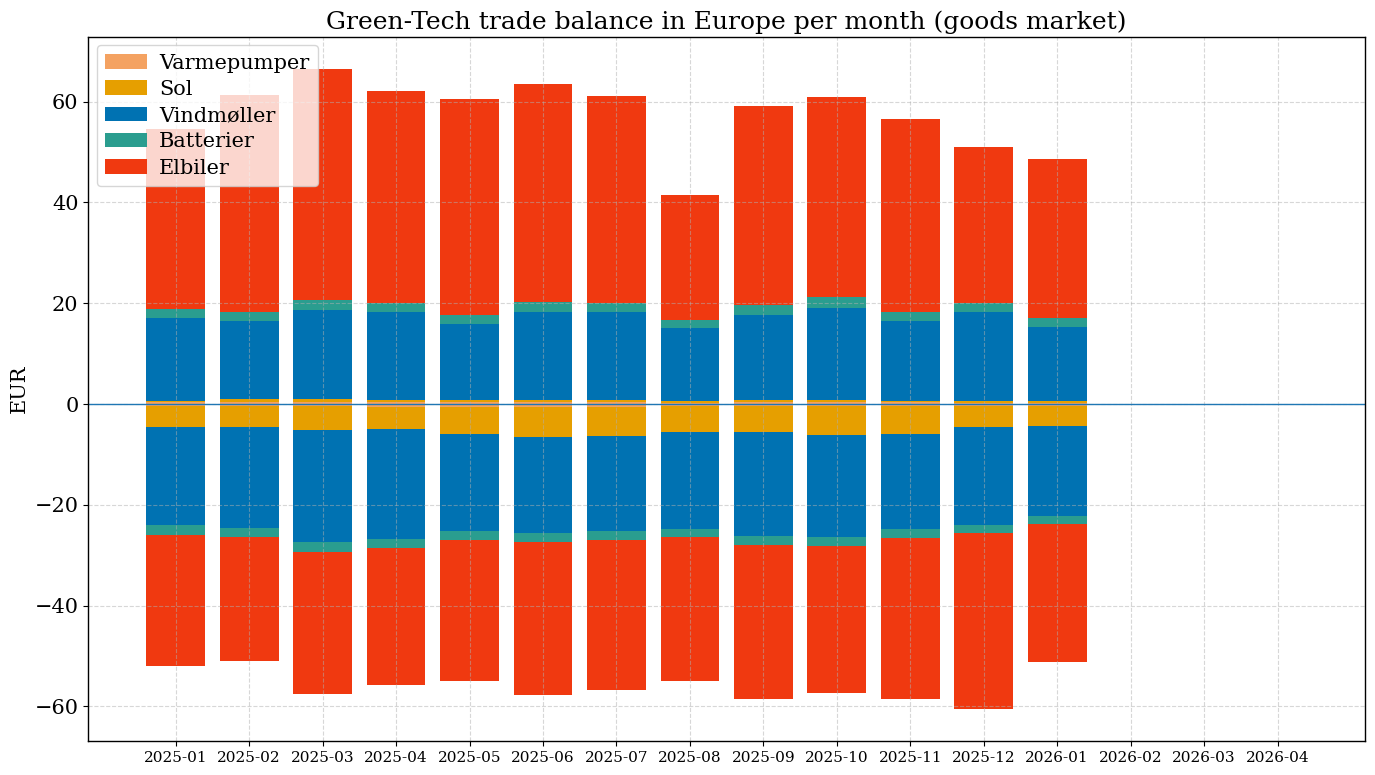

In [19]:
df = wide.copy()

# 0) time as datetime for nicer spacing (works for "YYYY-MM")
df["time"] = pd.to_datetime(df["time"], errors="coerce")

# 1) make matrices: rows=time, cols=category
X = df.pivot_table(index="time", columns="category", values="mX_DKK", aggfunc="sum").fillna(0.0)
M = df.pivot_table(index="time", columns="category", values="mM_DKK", aggfunc="sum").fillna(0.0)

# 2) align columns (same category order)
cats = sorted(set(X.columns) | set(M.columns))
X = X.reindex(columns=cats, fill_value=0.0)
M = M.reindex(columns=cats, fill_value=0.0)

# 3) plot: stacked exports (positive) + stacked imports (negative)
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(X.index))
bottom_pos = np.zeros(len(x))
bottom_neg = np.zeros(len(x))

cat_colors = {
    "Batterier":  "#2A9D8F",  # teal/green (storage)
    "Elbiler":    "#F03910",  # red/orange (EVs)
    "Sol":        "#E69F00",  # solar yellow
    "Varmepumper":"#F4A261",  # warm orange (heat)
    "Vindmøller": "#0072B2",  # wind blue
}
cats = ["Varmepumper", "Sol", "Vindmøller", "Batterier", "Elbiler"] 

for c in cats:
    ax.bar(x, X[c].to_numpy(), bottom=bottom_pos, width=0.8, label=c,
           color=cat_colors.get(c, None))
    bottom_pos += X[c].to_numpy()

for c in cats:
    ax.bar(x, -M[c].to_numpy(), bottom=bottom_neg, width=0.8,
           color=cat_colors.get(c, None))
    bottom_neg += -M[c].to_numpy()

# horizontal sparse ticks
target = 10
step = max(1, len(x) // target)
tick_idx = x[::step]
tick_lbl = [t.strftime("%Y-%m") if pd.notna(t) else "" for t in X.index[::step]]
ax.set_xticks(tick_idx)
ax.set_xticklabels(tick_lbl, rotation=0, ha="center")

# 4) basic formatting
ax.axhline(0, linewidth=1)
ax.set_title("Green-Tech trade balance in Europe per month (goods market)")
ax.set_ylabel("EUR")

# x ticks: show every Nth label to avoid clutter
target = 14
step = max(1, len(x) // target)
tick_idx = x[::step]
tick_lbl = [t.strftime("%Y-%m") if pd.notna(t) else "" for t in X.index[::step]]

ax.set_xticks(tick_idx)
ax.set_xticklabels(tick_lbl, rotation=0, ha="center")
ax.tick_params(axis="x", labelsize=11) 

# ax.legend(ncols=min(5, len(cats)), frameon=False, loc="upper left")
ax.legend(
    loc="upper left",
    frameon=True
)

ax.grid(True, which="both", linestyle="--", alpha=0.5)
fig.tight_layout()
plt.show()


*save*

In [20]:
# as png
fig.savefig(
    "clean_tech_trade_balance.png",
    dpi=300,         
    bbox_inches="tight"
)

# as xlsx
wide.to_excel("clean_tech_trade_balance.xlsx", index=False)